In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, log_loss
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

In [ ]:
df = pd.read_excel("Dataset_after_cleaning.xlsx")
df_gb = df.drop(columns=['ReturningVisitor', 'OtherVisitor', 'BounceRates', 'Region1', 'Month_5', 'OperatingSystem2', 'Browser2', 'PageValues'])
df_gb

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,SpecialDay,Month_2,Month_3,...,Region5,Region6,Region7,Region8,Region9,NewVisitor,IfWeekend,Y_IfRevenue,OperatingSystemOther,BrowserOther
0,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.100000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.0,1,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.140000,0.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.050000,0.0,1,0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.029031,0.0,0,0,...,0,0,0,0,0,0,1,0,1,1
12326,0,0.0,0,0.0,5,465.750000,0.021333,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12327,0,0.0,0,0.0,6,184.250000,0.086667,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
12328,4,75.0,0,0.0,15,346.000000,0.021053,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_gb.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'ExitRates', 'SpecialDay', 'Month_2', 'Month_3', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'OperatingSystem1', 'OperatingSystem3', 'Browser1', 'Region2',
       'Region3', 'Region4', 'Region5', 'Region6', 'Region7', 'Region8',
       'Region9', 'NewVisitor', 'IfWeekend', 'Y_IfRevenue',
       'OperatingSystemOther', 'BrowserOther'],
      dtype='object')

In [4]:
X = df_gb.drop('Y_IfRevenue', axis=1)
Y = df_gb['Y_IfRevenue']

#podział na zbiór testowy i walidacyjny
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.30, random_state=42, stratify=Y_train_val)

# Pierwszy model


Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91      2189
           1       0.47      0.05      0.09       401

    accuracy                           0.84      2590
   macro avg       0.66      0.52      0.50      2590
weighted avg       0.79      0.84      0.79      2590

              precision    recall  f1-score   support

           0       0.85      0.99      0.91      2189
           1       0.47      0.05      0.09       401

    accuracy                           0.84      2590
   macro avg       0.66      0.52      0.50      2590
weighted avg       0.79      0.84      0.79      2590



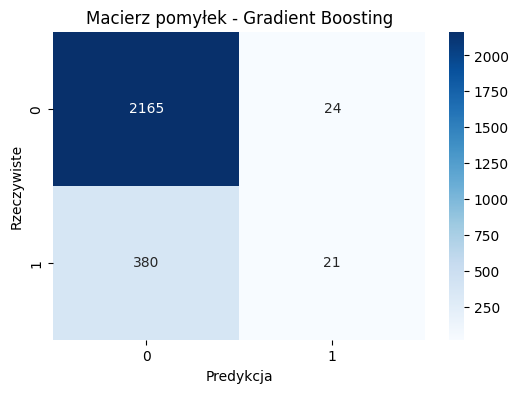

In [5]:
gb_model = GradientBoostingClassifier(random_state=42)

# Trening modelu
gb_model.fit(X_train, Y_train)

# Predykcja na zbiorze walidacyjnym
Y_val_pred = gb_model.predict(X_val)

# Ocena modelu
print("\nRaport klasyfikacji:\n", classification_report(Y_val, Y_val_pred))

#macierz pomyłek
cm = confusion_matrix(Y_val, Y_val_pred)
cm

print(classification_report(Y_val, Y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - Gradient Boosting")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

# Hist gb model

In [6]:
# przechodze na histgbmodel
hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced', 
    max_iter=300,        # odpowiednik n_estimators
    min_samples_leaf=100, 
    learning_rate=0.05,  # mniejszy krok uczenia daje lepszą stabilność
    random_state=42
)

hgb_model.fit(X_train, Y_train)
Y_val_pred = hgb_model.predict(X_val)
print("\nRaport klasyfikacji:\n", classification_report(Y_val, Y_val_pred))


Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.91      0.79      0.84      2189
           1       0.33      0.58      0.42       401

    accuracy                           0.75      2590
   macro avg       0.62      0.68      0.63      2590
weighted avg       0.82      0.75      0.78      2590



# Wagi klas (waga1: 10)

Trwa obliczanie metryk dla różnych wag...
Waga 1:1 zakończona.
Waga 1:2 zakończona.
Waga 1:3 zakończona.
Waga 1:4 zakończona.
Waga 1:5 zakończona.
Waga 1:6 zakończona.
Waga 1:8 zakończona.
Waga 1:10 zakończona.
Waga 1:12 zakończona.
Waga 1:15 zakończona.
Waga 1:20 zakończona.


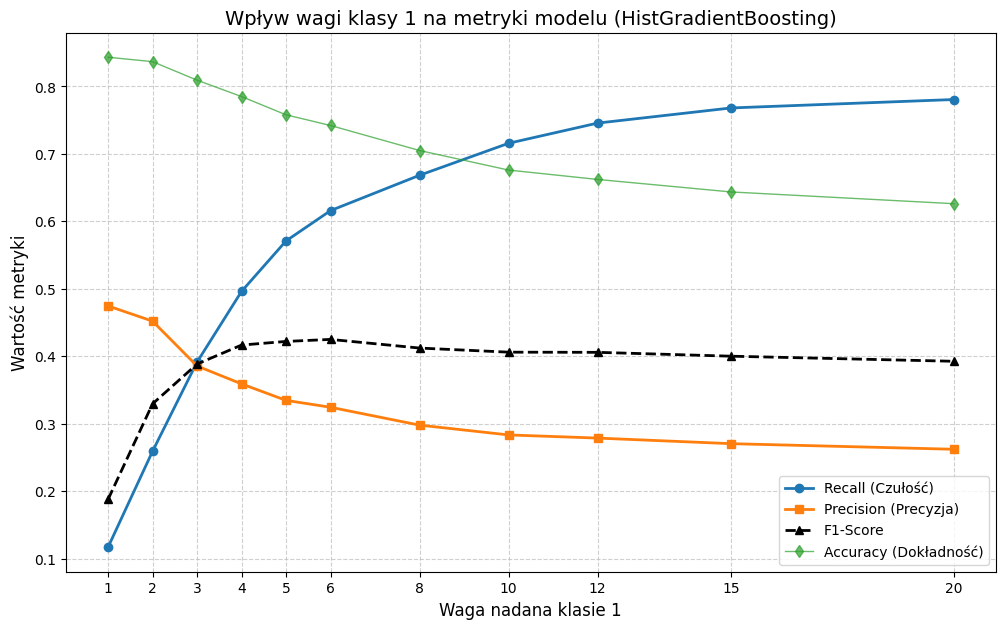

In [7]:
#wykres pokazujący zależność między wagami klas a metrykami

weights = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

# Listy na wyniki
results = {
    'recall': [],
    'precision': [],
    'f1': [],
    'accuracy': []
}

print("Trwa obliczanie metryk dla różnych wag...")

# 2. Pętla trenująca model dla każdej wagi
for w in weights:
    hgb_model = HistGradientBoostingClassifier(
        class_weight={0: 1, 1: w}, 
        random_state=42
    )
    
    hgb_model.fit(X_train, Y_train)
    y_pred = hgb_model.predict(X_val)
    
    # Zbieramy metryki (pos_label=1 oznacza, że interesuje nas klasa mniejszościowa)
    results['recall'].append(recall_score(Y_val, y_pred))
    results['precision'].append(precision_score(Y_val, y_pred, zero_division=0))
    results['f1'].append(f1_score(Y_val, y_pred))
    results['accuracy'].append(accuracy_score(Y_val, y_pred))
    print(f"Waga 1:{w} zakończona.")

# 3. Rysowanie wykresu
plt.figure(figsize=(12, 7))

plt.plot(weights, results['recall'], marker='o', label='Recall (Czułość)', linewidth=2)
plt.plot(weights, results['precision'], marker='s', label='Precision (Precyzja)', linewidth=2)
plt.plot(weights, results['f1'], marker='^', label='F1-Score', linewidth=2, color='black', linestyle='--')
plt.plot(weights, results['accuracy'], marker='d', label='Accuracy (Dokładność)', linewidth=1, alpha=0.7)

plt.title('Wpływ wagi klasy 1 na metryki modelu (HistGradientBoosting)', fontsize=14)
plt.xlabel('Waga nadana klasie 1', fontsize=12)
plt.ylabel('Wartość metryki', fontsize=12)
plt.xticks(weights)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Learning rate, early stopping, max iter

In [8]:
# dostosowuję parametry
hgb_model = HistGradientBoostingClassifier(
    class_weight={0: 1, 1: 10},   #wagi klas
    max_iter=1000,                #liczba iteracji
    learning_rate=0.1,            #mniejszy krok uczenia daje lepszą stabilność
    random_state=42,
    early_stopping=True,          #model przestaje dodawać nowe drzewa jak f.kosztu przestaje sie poprawiać
    validation_fraction=0.1,      # ile danych na wewnętrzną walidację
    n_iter_no_change=10,          # po ilu iteracjach bez poprawy stop
    tol=1e-4                      # jak mała poprawa jest uznana za brak poprawy
)

hgb_model.fit(X_train, Y_train)
Y_val_pred = hgb_model.predict(X_val)
print("\nRaport klasyfikacji:\n", classification_report(Y_val, Y_val_pred))


Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70      2189
           1       0.26      0.85      0.40       401

    accuracy                           0.60      2590
   macro avg       0.60      0.70      0.55      2590
weighted avg       0.84      0.60      0.65      2590



In [9]:
for lr in [0.01, 0.05, 0.1, 0.2]:
    model = HistGradientBoostingClassifier(
        class_weight={0: 1, 1: 10},
        learning_rate=lr,
        max_iter=2000,
        early_stopping=True,          
        validation_fraction=0.1,      
        n_iter_no_change=10,  
        random_state=42
    )
    model.fit(X_train, Y_train)
    print(lr, model.n_iter_, recall_score(Y_val, model.predict(X_val)))

0.01 218 0.8678304239401496
0.05 63 0.8478802992518704
0.1 29 0.8453865336658354
0.2 24 0.7930174563591023


In [10]:
# dostosowuję parametry
hgb_model = HistGradientBoostingClassifier(
    class_weight={0: 1, 1: 10},   #wagi klas
    max_iter=1000,                #liczba iteracji
    learning_rate=0.01,            #mniejszy krok uczenia daje lepszą stabilność
    random_state=42,
    early_stopping=True,          #model przestaje dodawać nowe drzewa jak f.kosztu przestaje sie poprawiać
    validation_fraction=0.1,      # ile danych na wewnętrzną walidację
    n_iter_no_change=10,          # po ilu iteracjach bez poprawy stop
    tol=1e-4                      # jak mała poprawa jest uznana za brak poprawy
)

hgb_model.fit(X_train, Y_train)
Y_val_pred = hgb_model.predict(X_val)
print("\nRaport klasyfikacji:\n", classification_report(Y_val, Y_val_pred))


Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.52      0.67      2189
           1       0.25      0.87      0.39       401

    accuracy                           0.57      2590
   macro avg       0.60      0.69      0.53      2590
weighted avg       0.85      0.57      0.63      2590



# Max leaf nodes, min leaf sample

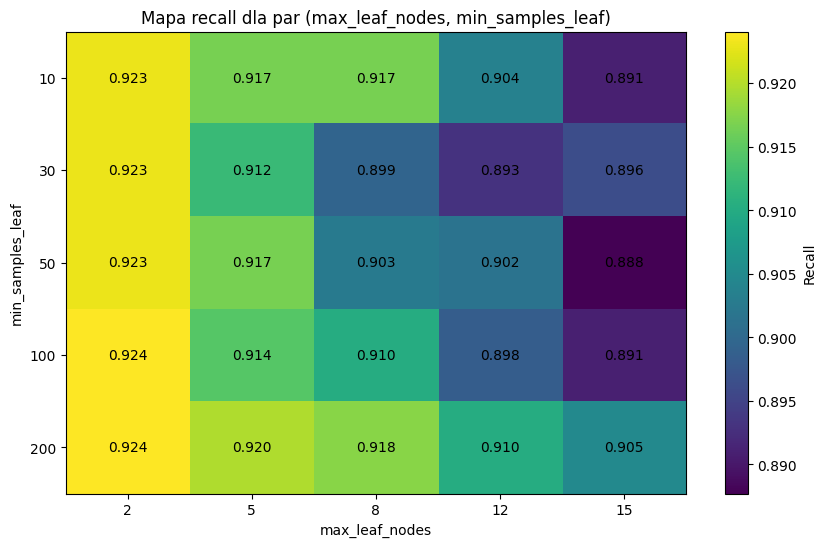

In [11]:
from sklearn.model_selection import cross_val_score

max_leaf_nodes_list = [2, 5, 8, 12, 15]
min_samples_leaf_list = [10, 30, 50, 100, 200]

scores = np.zeros((len(min_samples_leaf_list), len(max_leaf_nodes_list)))

for i, min_leaf in enumerate(min_samples_leaf_list):
    for j, max_leaf in enumerate(max_leaf_nodes_list):
        model = HistGradientBoostingClassifier(
            max_leaf_nodes=max_leaf,
            min_samples_leaf=min_leaf,
            class_weight={0: 1, 1: 10},   #wagi klas
            max_iter=1000,                #liczba iteracji
            learning_rate=0.01,            #mniejszy krok uczenia daje lepszą stabilność
            random_state=42,
            early_stopping=True,          #model przestaje dodawać nowe drzewa jak f.kosztu przestaje sie poprawiać
            validation_fraction=0.1,      # ile danych na wewnętrzną walidację
            n_iter_no_change=10,          # po ilu iteracjach bez poprawy stop
            tol=1e-4 
        )
        
        cv_scores = cross_val_score(
            model, X_train, Y_train,
            cv=5, scoring='recall'
        )
        
        scores[i, j] = cv_scores.mean()


# Wizualizacja
plt.figure(figsize=(10, 6))
im = plt.imshow(scores, aspect='auto')

plt.xticks(range(len(max_leaf_nodes_list)), max_leaf_nodes_list)
plt.yticks(range(len(min_samples_leaf_list)), min_samples_leaf_list)

plt.xlabel("max_leaf_nodes")
plt.ylabel("min_samples_leaf")
plt.title("Mapa recall dla par (max_leaf_nodes, min_samples_leaf)")
plt.colorbar(im, label="Recall")

for i in range(len(min_samples_leaf_list)):
    for j in range(len(max_leaf_nodes_list)):
        plt.text(j, i, f"{scores[i, j]:.3f}", ha="center", va="center")

plt.show()

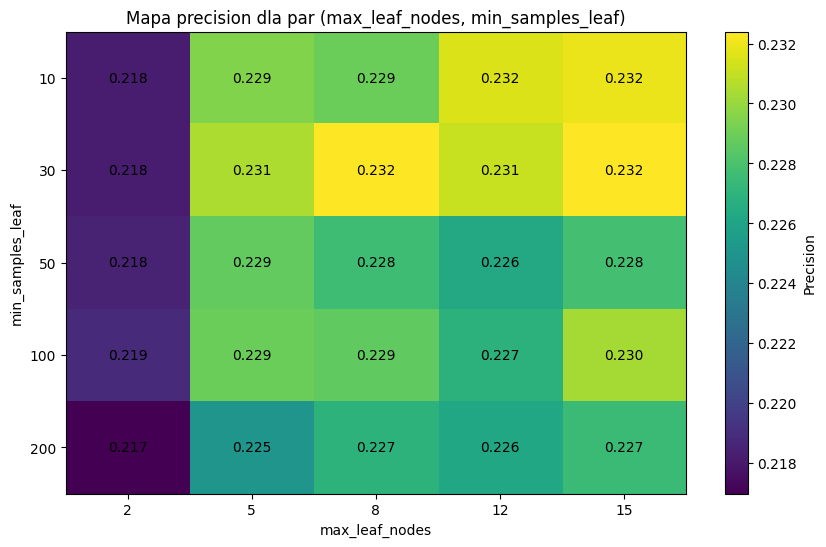

In [12]:
max_leaf_nodes_list = [2, 5, 8, 12, 15]
min_samples_leaf_list = [10, 30, 50, 100, 200]

scores_recall = np.zeros((len(min_samples_leaf_list), len(max_leaf_nodes_list)))
scores_precision = np.zeros((len(min_samples_leaf_list), len(max_leaf_nodes_list)))

for i, min_leaf in enumerate(min_samples_leaf_list):
    for j, max_leaf in enumerate(max_leaf_nodes_list):
        model = HistGradientBoostingClassifier(
            max_leaf_nodes=max_leaf,
            min_samples_leaf=min_leaf,
            class_weight={0: 1, 1: 10},
            max_iter=1000,
            learning_rate=0.01,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            tol=1e-4
        )

        scores_precision[i, j] = cross_val_score(
            model, X_train, Y_train, cv=5, scoring='precision'
        ).mean()

# Wizualizacja
plt.figure(figsize=(10, 6))
im = plt.imshow(scores_precision, aspect='auto')

plt.xticks(range(len(max_leaf_nodes_list)), max_leaf_nodes_list)
plt.yticks(range(len(min_samples_leaf_list)), min_samples_leaf_list)

plt.xlabel("max_leaf_nodes")
plt.ylabel("min_samples_leaf")
plt.title("Mapa precision dla par (max_leaf_nodes, min_samples_leaf)")
plt.colorbar(im, label="Precision")

for i in range(len(min_samples_leaf_list)):
    for j in range(len(max_leaf_nodes_list)):
        plt.text(j, i, f"{scores_precision[i, j]:.3f}", ha="center", va="center")

plt.show()



Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.45      0.61      2189
           1       0.23      0.92      0.37       401

    accuracy                           0.52      2590
   macro avg       0.60      0.68      0.49      2590
weighted avg       0.85      0.52      0.58      2590



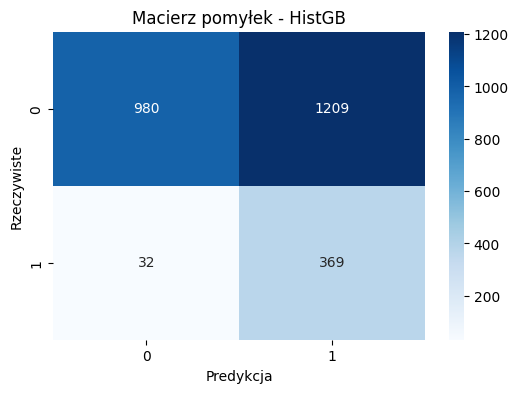

In [13]:
# ostateczny model
hgb_model = HistGradientBoostingClassifier(
    class_weight={0: 1, 1: 10},   #wagi klas
    max_leaf_nodes=5,
    min_samples_leaf=200,
    max_iter=1000,                #liczba iteracji
    learning_rate=0.01,            #mniejszy krok uczenia daje lepszą stabilność
    random_state=42,
    early_stopping=True,          #model przestaje dodawać nowe drzewa jak f.kosztu przestaje sie poprawiać
    validation_fraction=0.1,      # ile danych na wewnętrzną walidację
    n_iter_no_change=10,          # po ilu iteracjach bez poprawy stop
    tol=1e-4                      # jak mała poprawa jest uznana za brak poprawy
)

hgb_model.fit(X_train, Y_train)
Y_val_pred = hgb_model.predict(X_val)
print("\nRaport klasyfikacji:\n", classification_report(Y_val, Y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_val, Y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - HistGB")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

# Ocena na podst danych testowych


Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.43      0.60      3127
           1       0.23      0.90      0.36       572

    accuracy                           0.51      3699
   macro avg       0.59      0.67      0.48      3699
weighted avg       0.85      0.51      0.56      3699



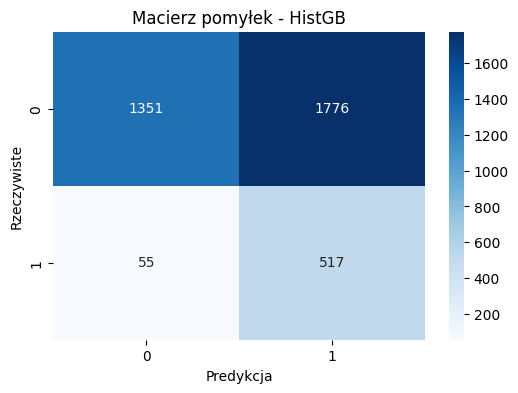

In [14]:
# ostateczny model
hgb_model = HistGradientBoostingClassifier(
    class_weight={0: 1, 1: 10},   #wagi klas
    max_leaf_nodes=5,             #maksymalna ilość liści (szerokość drzewa)
    min_samples_leaf=200,         #minimum obserwacji w liściu
    max_iter=1000,                #liczba iteracji
    learning_rate=0.01,           #mniejszy krok uczenia daje lepszą stabilność
    random_state=42,
    early_stopping=True,          #model przestaje dodawać nowe drzewa jak f.kosztu przestaje sie poprawiać
    validation_fraction=0.1,      # ile danych na wewnętrzną walidację
    n_iter_no_change=10,          # po ilu iteracjach bez poprawy stop
    tol=1e-4                      # jak mała poprawa jest uznana za brak poprawy
)

hgb_model.fit(X_train, Y_train)
Y_test_pred = hgb_model.predict(X_test)
print("\nRaport klasyfikacji:\n", classification_report(Y_test, Y_test_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(Y_test, Y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek - HistGB")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

# Ważności cech

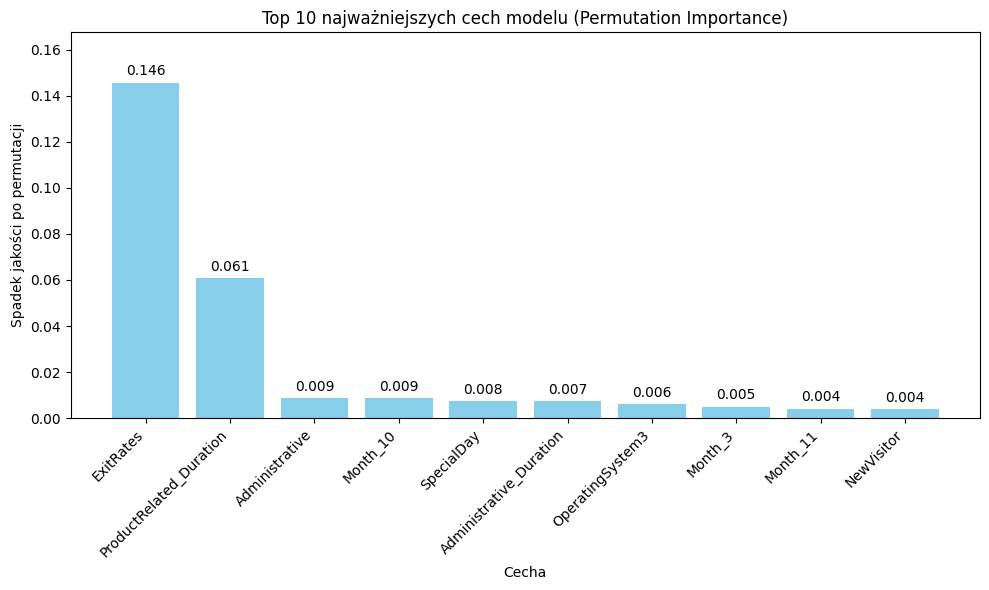

In [19]:
# Liczenie permutation importance
r = permutation_importance(
    hgb_model, 
    X_test, Y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1,
    scoring="recall"   # czułość dla klasy pozytywnej (1)
)

importances = r.importances_mean
feature_names = X_test.columns

# DataFrame z ważnościami
feat_imp = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

top10 = feat_imp.head(10)

# Wykres
plt.figure(figsize=(10, 6))
ax = plt.gca()

bars = ax.bar(top10['Cecha'], top10['Ważność'], color='skyblue')
ax.bar_label(bars, padding=3, fmt='%.3f')

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 najważniejszych cech modelu (Permutation Importance)")
plt.ylabel("Spadek jakości po permutacji")
plt.xlabel("Cecha")

plt.ylim(0, top10['Ważność'].max() * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
import shap

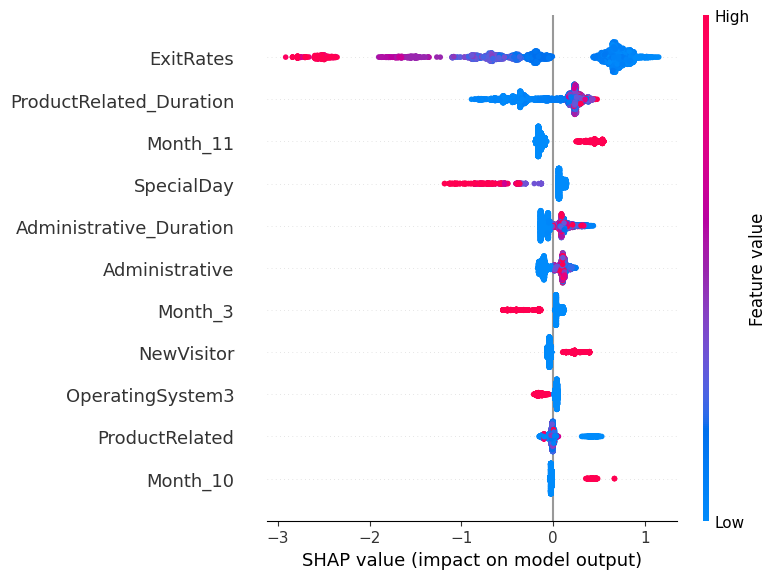

In [ ]:
#Wykres SHAPa

explainer = shap.TreeExplainer(hgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=11)


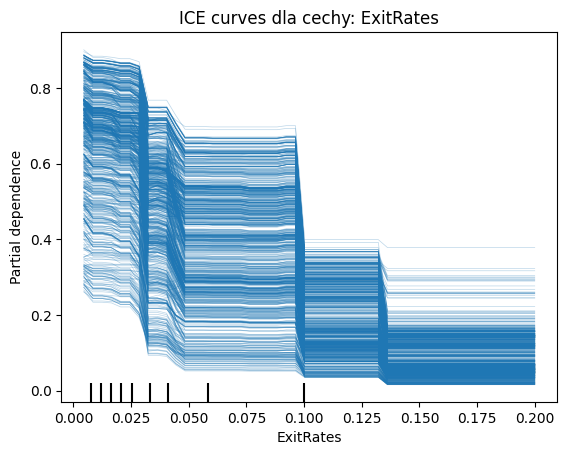

In [22]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature = "ExitRates"  # przykładowa nazwa cechy

PartialDependenceDisplay.from_estimator(
    hgb_model,
    X_test,
    [feature],
    kind="individual",   # ICE
    grid_resolution=50
)

plt.title(f"ICE curves dla cechy: {feature}")
plt.show()